## Feature Matching

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Method - Display Images
def display(image):
    plt.figure(figsize=(12,10)).add_subplot(111)
    plt.imshow(image, cmap= 'gray')
    plt.show()

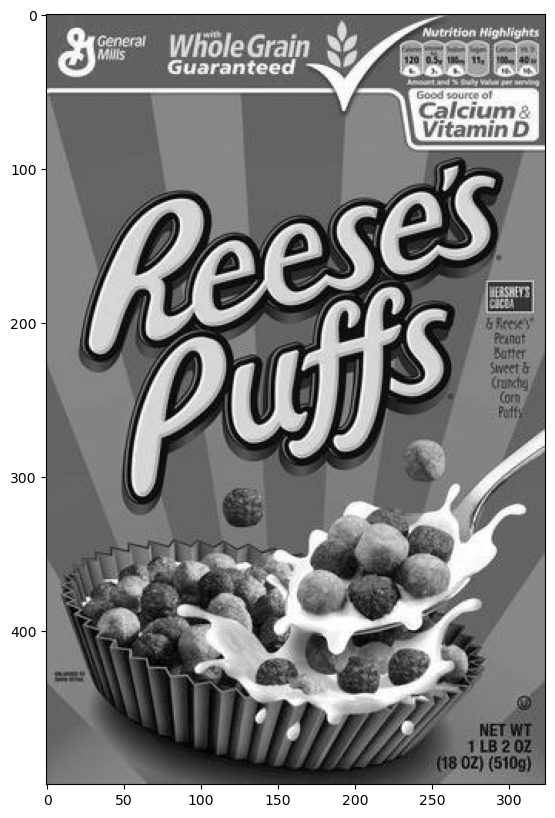

In [3]:
reeses  = cv2.imread('../dataset/img/reeses_puff.jpg',0)
display(reeses)

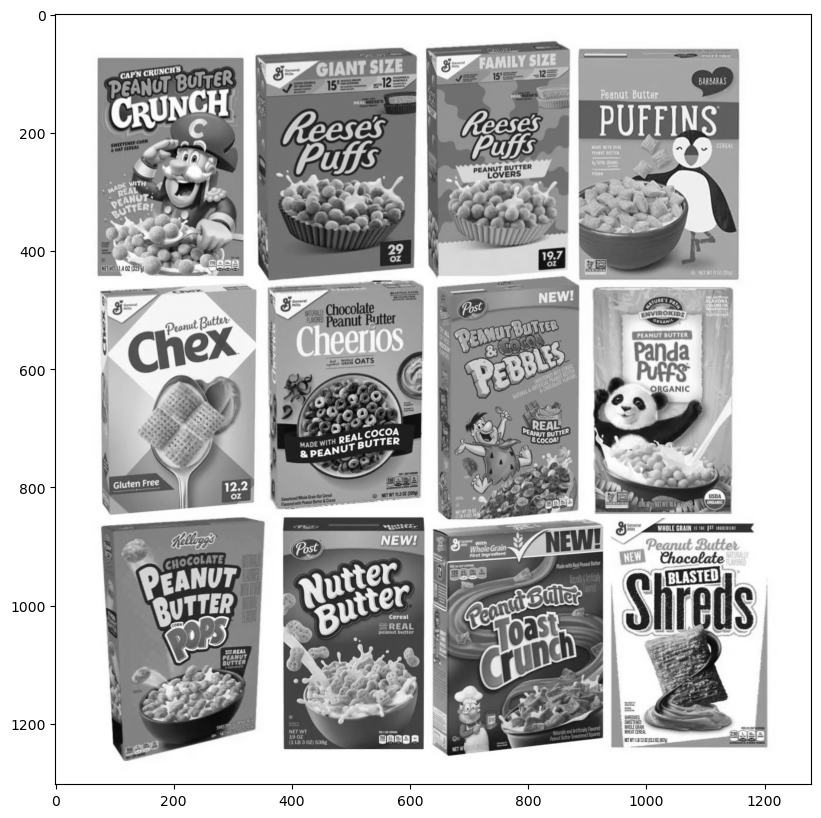

In [4]:
cereals = cv2.imread('../dataset/img/many_cereals.jpg',0)
display(cereals)

### Brute Force Detector with ORB Descriptor

In [5]:
# ORB
orb = cv2.ORB_create()

# Extracting key points using orb's method detectAndCompute we need to pass what image we want to detect and find Key features as well. 
# Second param is mask image if need otherwsie None.
keypoints1 , description1 = orb.detectAndCompute(reeses, None)
keypoints2 , description2 = orb.detectAndCompute(cereals, None)

# Brute force Matcher - NORM_HAMMING is default params
brute_force = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)

# Now we can check where the matches occurs in both images
matches = brute_force.match(description1, description2)

# matches variable conatins bunch of specialized match objects.
# Each match object conatins a attribute named distance which clarifies how good the match was. 
#   Less Distance - Better Match
#   More Distance - Wrost Match

# Distance Calculation - Sort the matches with respect to their distance 
# Standard way to use Distance Calculation is using lambda expression along with sort method
matches = sorted(matches, key = lambda x:x.distance)
len(matches) # After filtering we have 162 matches

162

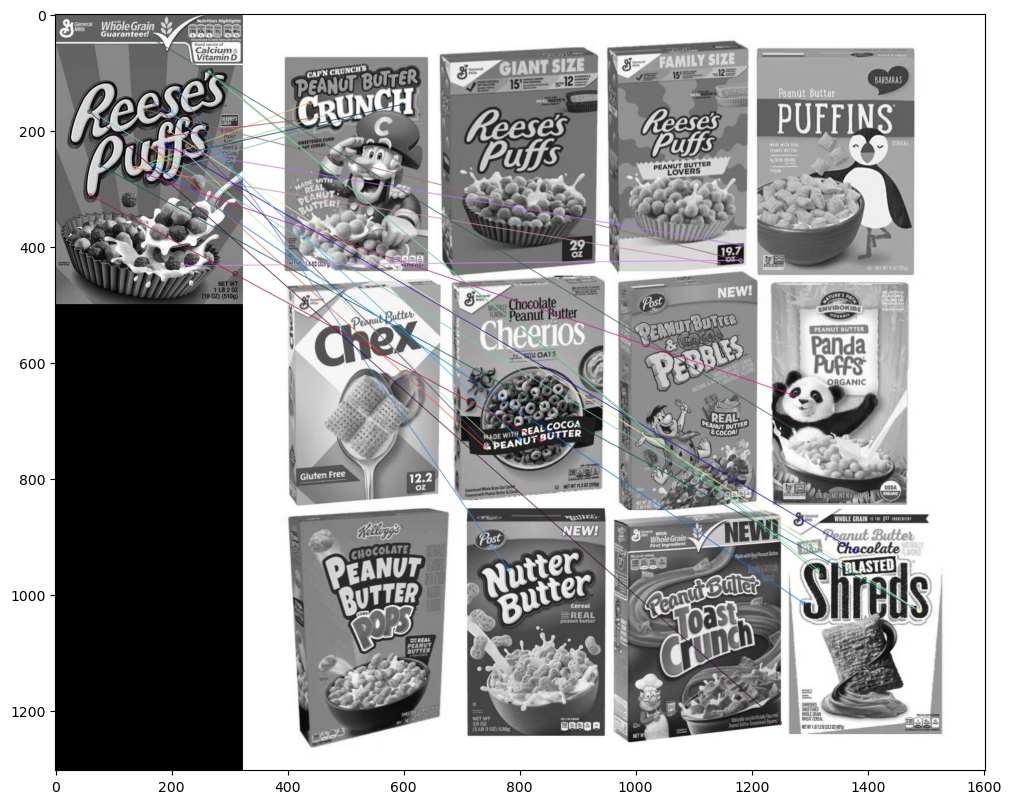

In [7]:
# Displaying matches

# we can display all the matches but for better visualization we are taking first 25 matchs and displaying it for better understanding
reeses_matches = cv2.drawMatches(reeses, keypoints1, cereals, keypoints2, matches[:25], None, flags=2)

# It is not good at matching because the way the input image and other image is slightly bend and letter/image positions are vary to match the exact.
# It is useful when the almost same feature precent in the other image otherwise it preforms low.
display(reeses_matches)